## Setup

In [8]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

df = pd.read_csv("data.csv")


# rename points
rename_dict = {
    'What gender do you identify as?': 'Gender',
    'How beneficial do you see the use of AI in these fields? [Therapists]': 'BenTher',
    'How beneficial do you see the use of AI in these fields? [Companionship]': 'BenComp',
    'In which areas do you find AI helpful in your workflow?  [Personal Advice / Therapy]': 'HelpTher',
    'In which areas do you find AI helpful in your workflow?  [Companionship]': 'HelpComp'
}
df = df.rename(columns=rename_dict)


# Select relevant columns
cols = ['Gender', 'BenTher', 'BenComp', 'HelpTher', 'HelpComp']
df_trim = df[cols].copy()


# extract first num and convert to numeric for benefit/helpfulness
for col in ['BenTher', 'BenComp', 'HelpTher', 'HelpComp']:
    df_trim[col] = pd.to_numeric(df_trim[col].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

df_trim = df_trim.dropna(subset=['BenTher', 'BenComp', 'HelpTher', 'HelpComp'])

# average sentiment
df_trim['Average_Sentiment'] = df_trim[['BenTher', 'BenComp', 'HelpTher', 'HelpComp']].mean(axis=1)

# create rounded sentiment for chi-square
df_trim['Rounded_Sentiment'] = df_trim['Average_Sentiment'].round().astype(int)

# binning gender
def map_gender(g):
    if g == 'Male':
        return 'Male'
    elif g == 'Female':
        return 'Female'
    else:
        return 'Other'
    
df_trim['Gender'] = df_trim['Gender'].apply(map_gender)

## Gender Distribution

C:\Users\rydun\AppData\Local\Temp\ipykernel_3972\4254757280.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='viridis', order=['Male', 'Female', 'Other'])


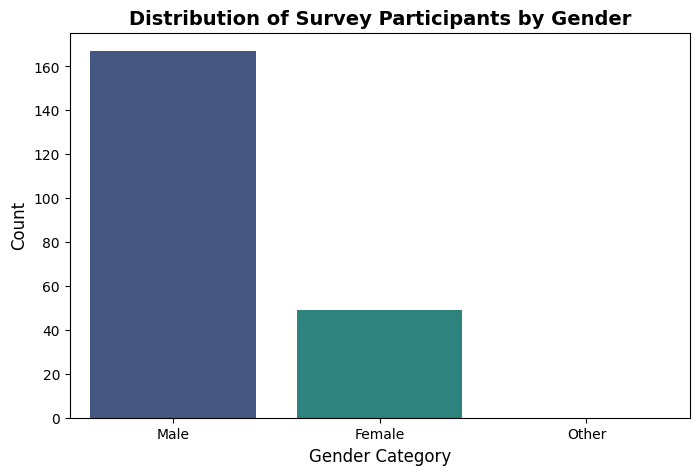

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Gender', palette='viridis', order=['Male', 'Female', 'Other'])
plt.title('Distribution of Survey Participants by Gender' ,fontsize=14, fontweight='bold')
plt.xlabel('Gender Category', fontsize = 12)
plt.ylabel('Count', fontsize = 12)

plt.show()

## Correlation Heatmap

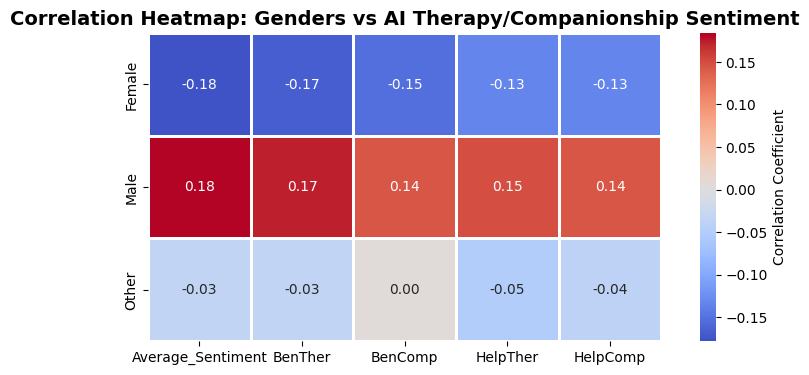

In [10]:
# Create a correlation heatmap to visualize relationships between all numeric variables

# categorize into male, female, other columns (assisted by Google Gemini LLM)
df_encoded = pd.get_dummies(df_trim, columns=['Gender'], dtype=int)
df_encoded = df_encoded.rename(columns={
    'Gender_Female': 'Female',
    'Gender_Male': 'Male',
    'Gender_Other': 'Other'
})

# Select only numeric columns for correlation analysis (excluding 'Gender' which is categorical)
# numeric_df = df.select_dtypes(include=[np.number])
genders = ['Female', 'Male', 'Other']
sentiments = ['Average_Sentiment', 'BenTher', 'BenComp', 'HelpTher', 'HelpComp']

heatmap_cols = ['Female', 'Male', 'Other', 'Average_Sentiment', 'BenTher', 'BenComp', 'HelpTher', 'HelpComp']
df_numeric = df_encoded[heatmap_cols]

# calculate the pairwise pearson's correlation of multiple columns. 'r' is the correlation matrix calculated
# full correlation matrix
full_corr = df_encoded[genders + sentiments].corr()
# correlation between gender and sentiments lists
gen_sent_corr = full_corr.loc[genders, sentiments]

# Set figure size for better readability
plt.figure(figsize=(10, 4))

# Create the heatmap
# center=0: Centers the color scale at 0 (important for correlations ranging from -1 to +1)
# cmap='coolwarm': Blue for negative correlations, red for positive correlations
# annot=True: Displays the correlation values in each cell
# fmt='.2f': Formats numbers to 2 decimal places
# square=True: Makes cells square-shaped for better appearance
# linewidths=1: Adds spacing between cells for clarity
sns.heatmap(gen_sent_corr, center=0, cmap='coolwarm', annot=True, fmt='.2f',
            square=True, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'})

# Add title
plt.title('Correlation Heatmap: Genders vs AI Therapy/Companionship Sentiment', fontsize=14, fontweight='bold')

# Display the plot
plt.show()

## Chi-Square Test

In [11]:
# create contingency table
contingency_table = pd.crosstab(df_trim['Gender'], df_trim['Rounded_Sentiment'])

# use contingency to run chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# print statistic
print(f"Chi-Square Statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.4f}")

# interpretation
alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject the Null Hypothesis.")
    print("Conclusion: There is a statistically significant correlation between gender and sentiment towards the use of AI as a therapeutic service or companionship.")
else:
    print("\nResult: Fail to reject the Null Hypothesis.")
    print("Conclusion: There is no significant correlation between gender and sentiment towards the use of AI as a therapeutic service or companionship.")

Chi-Square Statistic: 8.13
P-value: 0.6164

Result: Fail to reject the Null Hypothesis.
Conclusion: There is no significant correlation between gender and sentiment towards the use of AI as a therapeutic service or companionship.
